In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats

In [2]:
#open the output file

import os

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/SHM_T1_fixedIC_fitall.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

In [3]:
# open experimental data file 
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_new = df_new.sort_values(by='Age at S1K')
print(df_new)

df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')




                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [4]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df_new['agebin'] = pd.cut(df_new['Age at BMT'], bins=[0, 61, 81, 101], labels=['agebin1 = [41,61]', 'agebin2 = [62,81]', 'agebin3 = [82,101]'])
print(df_new)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

/tmp/ipykernel_681816/1847585974.py:74: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_3.set_xlim(0, 800)
/tmp/ipykernel_681816/1847585974.py:93: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_4.set_xlim(0, 800)
/tmp/ipykernel_681816/1847585974.py:111: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_5.set_xlim(0, 800)


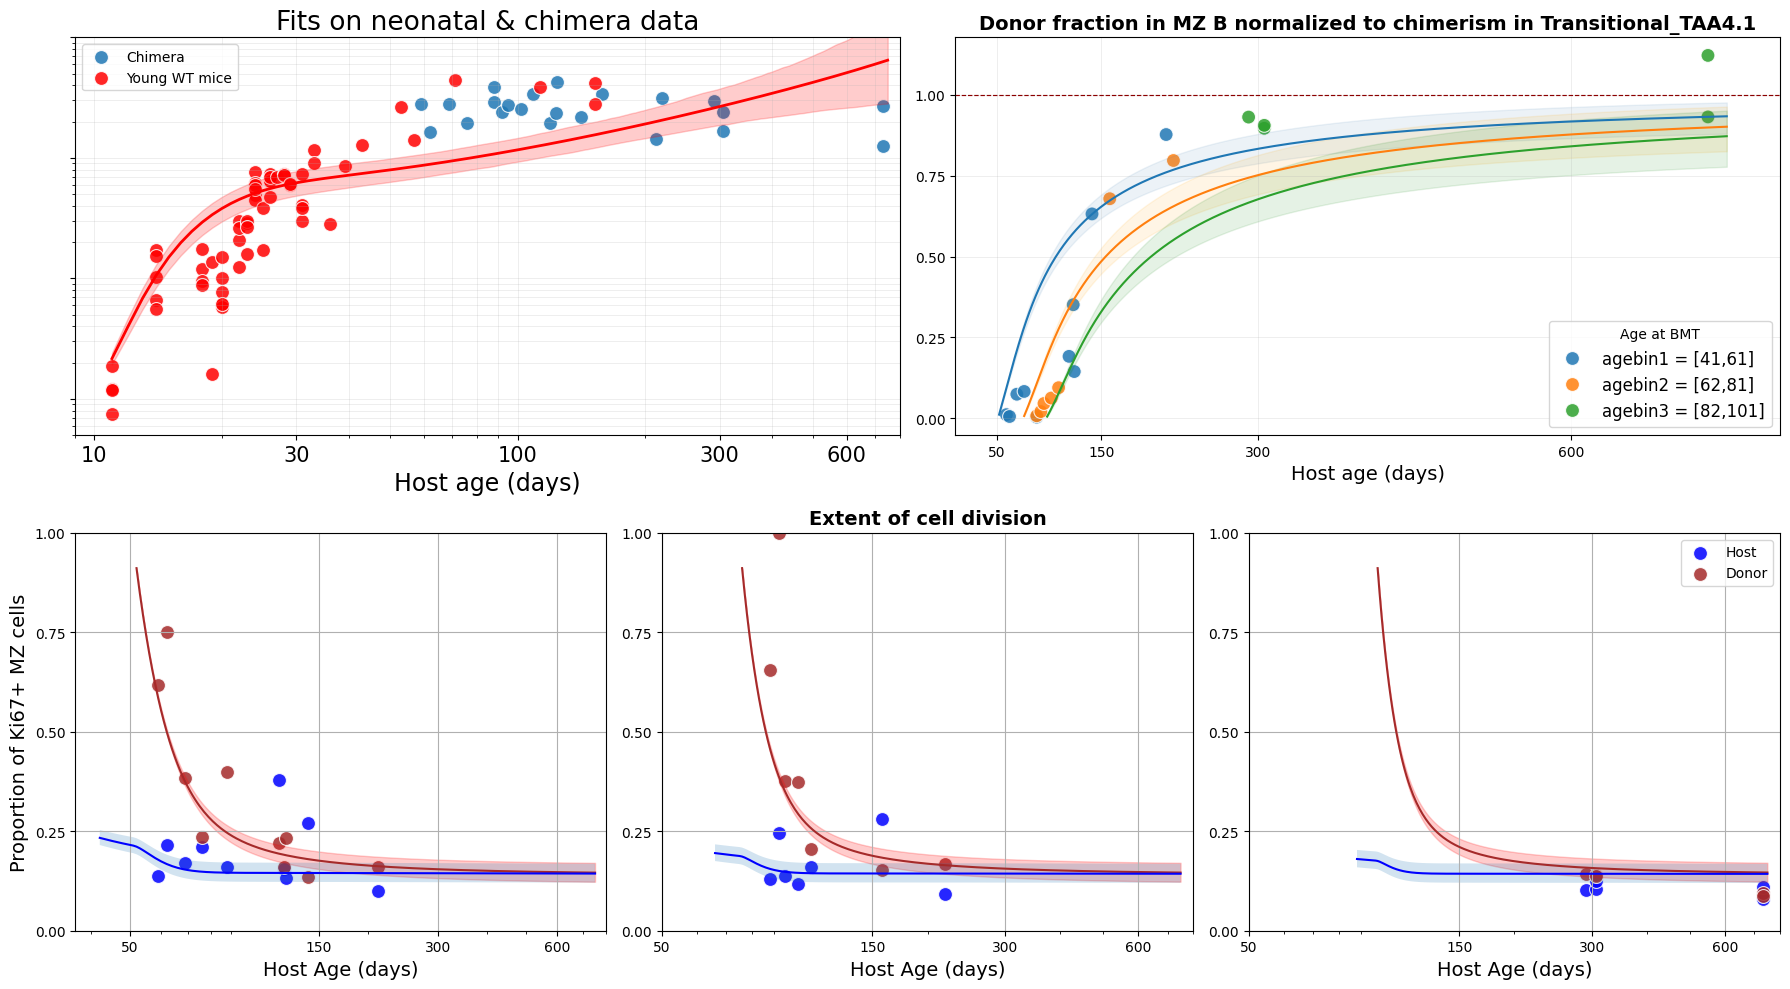

In [5]:
ts = np.arange(11, 750, 1)
ts1= np.arange(42, 750, 1)
ts2= np.arange(66, 750, 1)
ts3= np.arange(88, 750, 1)

# Plotting
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 6)  # Create a GridSpec with 2 rows and 4 columns

# Create the subplots
ax1 = fig.add_subplot(gs[0, 0:3])  # First row, spanning columns 0 to 1
ax2 = fig.add_subplot(gs[0, 3:6])  # First row, spanning columns 2 to 3
# second row has 3 plots based on the age at BMT
ax_3 = fig.add_subplot(gs[1, 0:2])  # First row, spanning columns 0 to 1
ax_4 = fig.add_subplot(gs[1, 2:4])  # First row, spanning columns 2 to 3
ax_5 = fig.add_subplot(gs[1, 4:6])  # First row, spanning columns 2 to 3 

# Plot the Mz counts
sns.scatterplot(ax=ax1, data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85, s=100, label='Chimera', legend=False)
sns.scatterplot(ax=ax1, data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
ax1.plot(ts, np.mean(data_neutral.totalMz_pred, axis=0), color='red', linewidth=2)
ax1.fill_between(ts, np.quantile(data_neutral.totalMz_pred, 0.025, axis=0), np.quantile(data_neutral.totalMz_pred, 0.975, axis=0), alpha=0.2, color='red')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5 * 1e3, 1e7)
ax1.set_xlim(9, 800)
ax1.set_xticks([10, 30, 100, 300, 600])
ax1.set_xticklabels([10, 30, 100, 300, 600])
ax1.set_title('Fits on neonatal & chimera data', fontsize=19)
ax1.set_xlabel('Host age (days)', fontsize=17)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.tick_params(axis='both', labelsize=15) 
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax1.legend()

# Plot normalized donor fraction

sns.scatterplot(ax=ax2, data=df_new, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100)
ax2.plot(ts1, np.mean(data_neutral.Nfd_pred1, axis=0))
ax2.plot(ts2, np.mean(data_neutral.Nfd_pred2, axis=0))
ax2.plot(ts3, np.mean(data_neutral.Nfd_pred3, axis=0))
ax2.fill_between(ts1, np.quantile(data_neutral.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred1, 0.975, axis=0), alpha=0.1, color= 'steelblue')
ax2.fill_between(ts2, np.quantile(data_neutral.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred2, 0.975, axis=0), alpha=0.1, color = 'orange')
ax2.fill_between(ts3, np.quantile(data_neutral.Nfd_pred3, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred3, 0.975, axis=0), alpha=0.1, color = 'green')
# ax2.set_xscale('log')
ax2.set_xlim(10, 800)
ax2.set_xticks([50, 150,  300,  600])
ax2.set_xticklabels([50, 150,  300,  600])
#ax2.set_xticks(np.arange(0, 750, 100))
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=14)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in Transitional_TAA4.1', fontsize=14, fontweight='bold')
ax2.axhline(y=1, color='darkred', linestyle='dashed', linewidth=0.85)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax2.legend(title='Age at BMT', fontsize=12)

#Construct a new dataframe for agebin1, agebin2 and agebin3
df_Ki67_bin1 = df_new[df_new['agebin'] == 'agebin1 = [41,61]']
df_Ki67_bin2 = df_new[df_new['agebin'] == 'agebin2 = [62,81]']
df_Ki67_bin3 = df_new[df_new['agebin'] == 'agebin3 = [82,101]']

# Plot Proportion of Ki67+ MZ cells for age bin1
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax_3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax_3.plot(ts1, np.mean(data_neutral.donor_ki_pred1, axis=0), color= 'brown')
ax_3.fill_between(ts1, np.quantile(data_neutral.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred1, 0.975, axis=0), color= 'red', alpha=0.2)
ax_3.plot(ts1, np.mean(data_neutral.host_ki_pred1, axis=0), color = 'blue')
ax_3.fill_between(ts1, np.quantile(data_neutral.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred1, 0.975, axis=0), alpha=0.2)
ax_3.set_ylim(0, 1)
ax_3.set_yticks(np.arange(0, 1.25, 0.25))
ax_3.set_xscale('log')
ax_3.set_xlim(0, 800)
ax_3.set_xticks([50, 150, 300, 600])
ax_3.set_xticklabels([50, 150, 300, 600])
ax_3.set_ylabel('Proportion of Ki67+ MZ cells', fontsize=14)
ax_3.set_xlabel('Host Age (days)', fontsize=14)
# ax_3.set_title('Extent of cell division', fontsize=14, fontweight='bold')
ax_3.grid(True, ls="solid")


# Plot Proportion of Ki67+ MZ cells for age bin2
sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax_4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax_4.plot(ts2, np.mean(data_neutral.donor_ki_pred2, axis=0), color= 'brown')
ax_4.fill_between(ts2, np.quantile(data_neutral.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred2, 0.975, axis=0), color= 'red', alpha=0.2)
ax_4.plot(ts2, np.mean(data_neutral.host_ki_pred2, axis=0), color = 'blue')
ax_4.fill_between(ts2, np.quantile(data_neutral.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred2, 0.975, axis=0), alpha=0.2)
ax_4.set_ylim(0, 1)
ax_4.set_yticks(np.arange(0, 1.25, 0.25))
ax_4.set_xscale('log')
ax_4.set_xlim(0, 800)
ax_4.set_xticks([50, 150, 300, 600])
ax_4.set_xticklabels([50, 150, 300, 600])
ax_4.set_ylabel('')
ax_4.set_xlabel('Host Age (days)', fontsize=14)
ax_4.set_title('Extent of cell division', fontsize=14, fontweight='bold')
ax_4.grid(True, ls="solid")


sns.scatterplot(ax=ax_5, data=df_Ki67_bin3, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax_5, data=df_Ki67_bin3, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax_5.plot(ts3, np.mean(data_neutral.donor_ki_pred3, axis=0), color= 'brown')
ax_5.fill_between(ts3, np.quantile(data_neutral.donor_ki_pred3, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred3, 0.975, axis=0), color= 'red', alpha=0.2)
ax_5.plot(ts3, np.mean(data_neutral.host_ki_pred3, axis=0), color = 'blue')
ax_5.fill_between(ts3, np.quantile(data_neutral.host_ki_pred3, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred3, 0.975, axis=0), alpha=0.2)
ax_5.set_ylim(0, 1)
ax_5.set_yticks(np.arange(0, 1.25, 0.25))
ax_5.set_xscale('log')
ax_5.set_xlim(0, 800)
ax_5.set_xticks([50, 150, 300, 600])
ax_5.set_xticklabels([50, 150, 300, 600])
ax_5.set_ylabel('')
ax_5.set_xlabel('Host Age (days)', fontsize=14)
# ax_5.set_title('Extent of cell division', fontsize=14, fontweight='bold')
ax_5.grid(True, ls="solid")
ax_5.legend(labels=['Host', 'Donor'])

plt.tight_layout()

#Save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/new_output/SHM_fitall_T1.png', dpi=300, bbox_inches='tight')


In [6]:
# Calculate elpdf for the model

idata = az.from_cmdstanpy(data_neutral, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Compute Loo CV for models with several Likelihoods 
import xarray as xr

# Concatenate the log_likelihood arrays

a1 = np.array(idata.log_likelihood["log_lik_Mz"])
a2 = np.array(idata.log_likelihood["log_lik_Nfd"])
a3 = np.array(idata.log_likelihood["log_lik_Kid"])
a4 = np.array(idata.log_likelihood["log_lik_Kih"])

log_lik = np.concatenate((a1, a2, a3, a4), axis=2)

# Convert the concatenated array to an xarray DataArray
idata.log_likelihood["combined_log_lik"] = xr.DataArray(log_lik, dims=["chain", "draw", "log_likelihood_dim"], coords={"chain": np.arange(log_lik.shape[0]), "draw": np.arange(log_lik.shape[1]), "log_likelihood_dim": np.arange(log_lik.shape[2])})

# Compute loo_cv
loo = loo_result1_combined = az.loo(idata, var_name="combined_log_lik")
print(loo)

arviz - WARNING - Array contains NaN-value.


Computed from 1000 posterior samples and 128 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -129.33    12.28
p_loo        9.25        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.67]   (good)      126   98.4%
   (0.67, 1]   (bad)         2    1.6%
   (1, Inf)   (very bad)    0    0.0%



/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


[ 6.28362959e+02 -6.24456919e+04  3.40328561e+02  5.61480098e+02
  9.50037254e+02 -1.84347654e+04 -5.16503115e+03  3.22169268e+02
 -2.96254725e+02 -3.47790858e+03 -5.41521235e+02 -2.34567574e+03
  5.05356650e+02  1.00733495e+03 -1.96081239e+03 -8.59770752e+02
 -6.22605929e+02  3.21198879e+03 -1.10797184e+03 -2.93457739e+03
  2.78932467e+03  2.85480717e+03  9.78330530e+02 -5.14624085e+02
  1.98495756e+03 -4.12587607e+04  5.45398679e+02 -8.68823240e+02
  9.60303658e+02  3.25972150e+02 -4.11192490e+02  8.95192019e+02
  1.81689956e+03 -7.14584722e+04 -3.54895899e+02 -2.11003708e+03
  2.70201216e+02  3.16101414e+02  1.77994756e+02  3.88448319e+02
  1.67184559e+03 -1.54444559e+03 -4.78428479e+02  1.02597274e+03
 -5.42793407e+02  3.15784593e+03 -5.89962704e+02  5.52484601e+02
  1.21540800e+03  2.39760353e+03 -1.61047207e+03  9.72974706e+02
  2.83298803e+02  7.74466124e+02 -2.66502818e+02 -5.62208760e+02
  6.19379127e+02  3.41957169e+03  5.28555117e+02  5.18822740e+03
 -1.46079490e+03  7.34032

<Axes: ylabel='Density'>

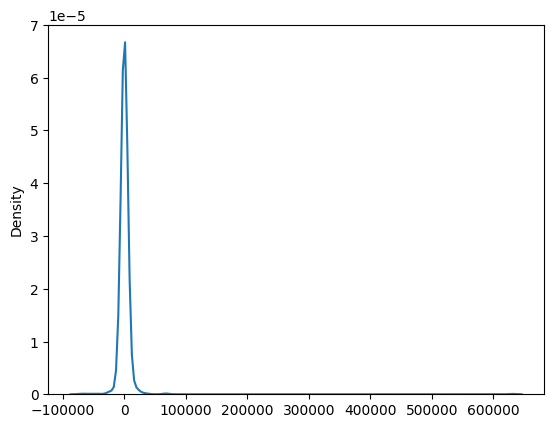

In [7]:
netloss = 1/ (data_neutral.delta - data_neutral.rho)
clonallife = np.log(2)*netloss
print(clonallife)
print(np.mean(clonallife))
sns.kdeplot(clonallife)


# #plot interdivision time

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(data_neutral.rho_inv, axis=0), color='red')
# axes.fill_between(ts1, np.quantile(interdiv, 0.025, axis=0), np.quantile(interdiv, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 100)
# axes.set_xlim(0, 730)
# axes.set_ylabel('Interdivision time (days)')
# axes.set_xlabel('Mouse Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
# #plt.savefig('Interdivision_time.png')
# plt.show()

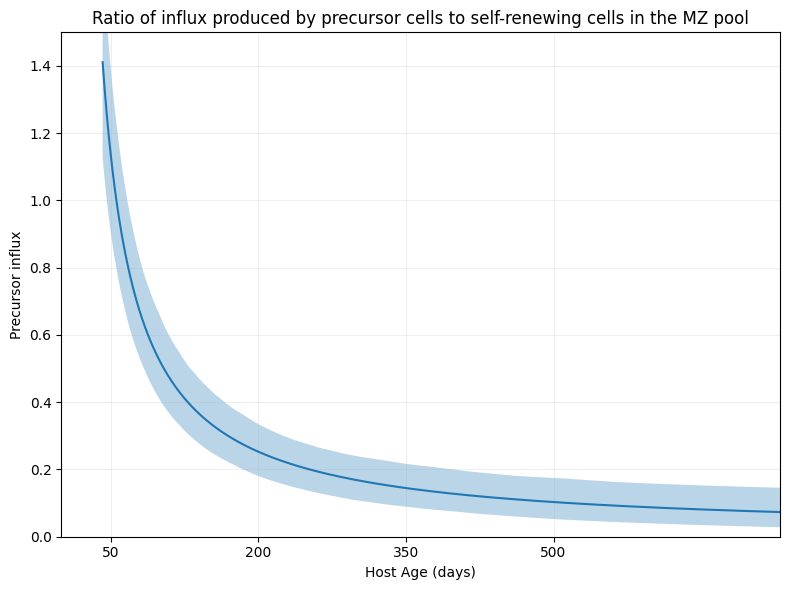

In [8]:
# Define 2D array for influx of shape (10000, 705)

influx = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
	influx[:, i] = (data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i])
 

# CI for precursor 

# influx = []
# for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# 	influx.append((data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i]))

# influx = np.array(influx)
# print(len(influx))
# print(influx.shape)
# print(np.quantile(influx, 0.025, axis=0))
# print(np.quantile(influx, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx, axis=0))
axes.fill_between(ts1, np.quantile(influx, 0.025, axis=0), np.quantile(influx, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 1.5)
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Precursor influx')
axes.set_xlabel('Host Age (days)')
axes.set_title('Ratio of influx produced by precursor cells to self-renewing cells in the MZ pool') 
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()


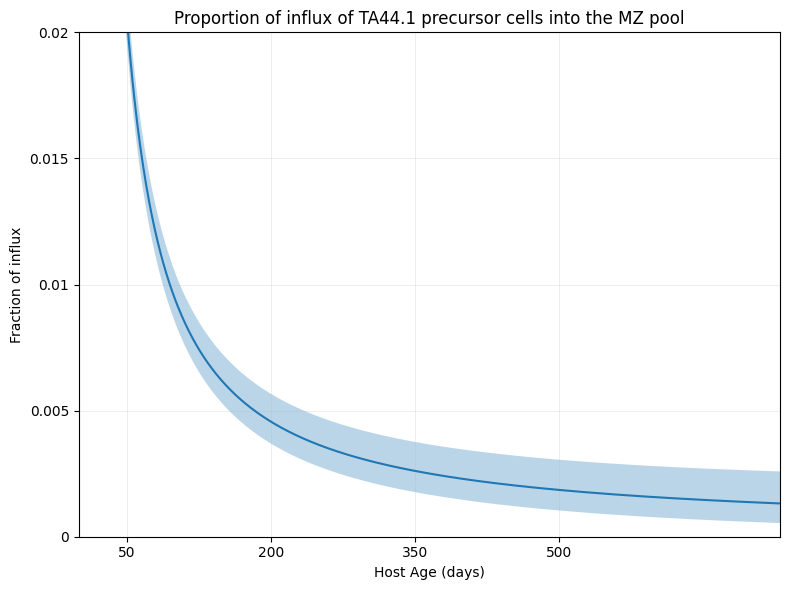

In [9]:
influx_p = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
	influx_p[:, i] = (data_neutral.phi * 1118208) / data_neutral.MZ_counts_pred1[:, i]
 

# # influx = np.array(influx)
# print(np.quantile(influx_p, 0.025, axis=0))
# print(np.quantile(influx_p, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx_p, axis=0))
axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
plt.tight_layout()
plt.show()


In [10]:
# Daily influx of precursor cells

print(np.mean(data_neutral.phi*1118208))

# Calculate credible interval 

print(np.quantile(data_neutral.phi*1118208, 0.025))
print(np.quantile(data_neutral.phi*1118208, 0.975))

5911.41023735808
4542.083739647999
7451.967344639999


In [11]:
# print(np.mean(data_neutral.delta))

print(data_neutral.rho.shape)
print(len(data_neutral.MZ_counts_pred1[0]))
# print(data_neutral.rho * data_neutral.MZ_counts_pred1)
# print(np.mean(data_neutral.lamda_inv))
# print(np.mean(data_neutral.beta_inv))
# print(np.mean(data_neutral.rho_inv))
# print(data_neutral.rho * data_neutral.MZ_counts_pred1[15])
# Mz_60 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15]
# print(np.mean(Mz_60))
# # print((data_neutral.MZ_counts_pred1[:, 15]))
# #calculate credible interval

# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.025))
# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.975))

# print('Credible interval for MZ cells at 60 days:', np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], [0.025, 0.975]))




(1000,)
708


In [12]:
Mz_350 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305]
print(np.mean(Mz_350))
print((data_neutral.MZ_counts_pred1[:, 305]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.975))

42176.04201163501
[2299800. 2661930. 2104390. 2149180. 2321070. 2039240. 2099590. 1992950.
 2873050. 2326910. 2932140. 2204690. 2142950. 2371560. 2384440. 2444090.
 2492110. 2242470. 3065300. 2010800. 2392610. 2212790. 2566940. 2269810.
 2259900. 2273240. 1884650. 2722280. 1931530. 2000130. 3168060. 2201530.
 2039980. 2102880. 2662470. 1830760. 1957890. 1475390. 1571100. 2143670.
 2216040. 2346480. 2870080. 2135650. 3051330. 2078070. 2401680. 2066540.
 2064330. 2043210. 2343590. 2186990. 1696090. 1712410. 3068420. 3312730.
 1987150. 1882770. 1853950. 2725970. 1836750. 2102020. 2436400. 2328760.
 1855650. 2836640. 2222650. 2961450. 2832760. 2271480. 2212830. 2055430.
 2512190. 2142770. 2375440. 2290960. 2384540. 2038750. 2025510. 2507950.
 1959170. 2903340. 3131560. 1702750. 2085570. 2079540. 1966510. 1942360.
 2264520. 2041060. 2203080. 2158130. 2124870. 2064970. 2290730. 2304860.
 2433720. 2289520. 1910780. 2093730. 2362820. 2409280. 1951520. 2564830.
 2027620. 2871590. 1819740. 26877

In [13]:
Mz_600 = data_neutral.rho * data_neutral.MZ_counts_pred3[:, 555]
print(np.mean(Mz_600))
print((data_neutral.MZ_counts_pred1[:, 555]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.975))

82021.703060787
[ 3524130.  4633730.  2950470.  3248850.  3701950.  3559420.  3710000.
  2766640.  7041430.  4147010.  6074660.  3977910.  3195410.  3800080.
  4335830.  4726300.  5035660.  3794990.  5784110.  3599370.  4033770.
  3732550.  4104470.  4746610.  3764270.  3958540.  2837750.  5259400.
  3082040.  2782520.  6984250.  3493610.  3384260.  3657990.  6121780.
  3315730.  2628210.  2039790.  1928320.  3073800.  3662830.  4320760.
  6098850.  3426080.  6319250.  3514580.  4896400.  3117360.  3350950.
  3426790.  4304900.  3494280.  2297510.  2680450.  7863340.  6816990.
  3039040.  3189930.  2780150.  4661410.  3391440.  3274620.  4318700.
  4061910.  2991070.  5322490.  3424670.  5760220.  4388860.  4923420.
  3164750.  2768880.  4676640.  3564290.  4215390.  4267310.  5722390.
  2943350.  3189090.  4808050.  2996070.  5546520.  7350600.  2414890.
  3085470.  3063850.  3398840.  3246410.  4373710.  3674620.  4289310.
  3444000.  3515090.  3409010.  3645190.  4081820.  4523180. 

[ 6.28362959e+02 -6.24456919e+04  3.40328561e+02  5.61480098e+02
  9.50037254e+02 -1.84347654e+04 -5.16503115e+03  3.22169268e+02
 -2.96254725e+02 -3.47790858e+03 -5.41521235e+02 -2.34567574e+03
  5.05356650e+02  1.00733495e+03 -1.96081239e+03 -8.59770752e+02
 -6.22605929e+02  3.21198879e+03 -1.10797184e+03 -2.93457739e+03
  2.78932467e+03  2.85480717e+03  9.78330530e+02 -5.14624085e+02
  1.98495756e+03 -4.12587607e+04  5.45398679e+02 -8.68823240e+02
  9.60303658e+02  3.25972150e+02 -4.11192490e+02  8.95192019e+02
  1.81689956e+03 -7.14584722e+04 -3.54895899e+02 -2.11003708e+03
  2.70201216e+02  3.16101414e+02  1.77994756e+02  3.88448319e+02
  1.67184559e+03 -1.54444559e+03 -4.78428479e+02  1.02597274e+03
 -5.42793407e+02  3.15784593e+03 -5.89962704e+02  5.52484601e+02
  1.21540800e+03  2.39760353e+03 -1.61047207e+03  9.72974706e+02
  2.83298803e+02  7.74466124e+02 -2.66502818e+02 -5.62208760e+02
  6.19379127e+02  3.41957169e+03  5.28555117e+02  5.18822740e+03
 -1.46079490e+03  7.34032

<Axes: ylabel='Density'>

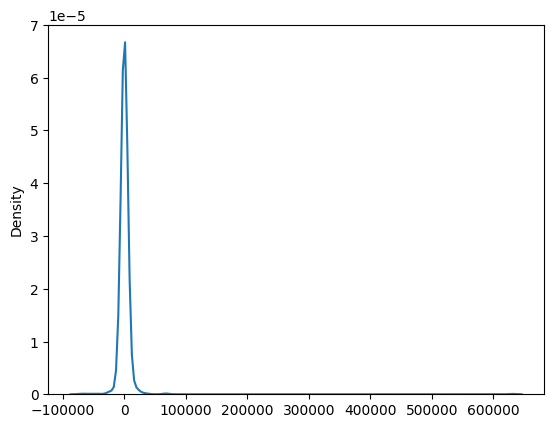

In [14]:
netloss = 1/ (data_neutral.delta - data_neutral.rho)
clonallife = np.log(2)*netloss
print(clonallife)
print(np.mean(clonallife))
sns.kdeplot(clonallife)


# #plot interdivision time

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(data_neutral.rho_inv, axis=0), color='red')
# axes.fill_between(ts1, np.quantile(interdiv, 0.025, axis=0), np.quantile(interdiv, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 100)
# axes.set_xlim(0, 730)
# axes.set_ylabel('Interdivision time (days)')
# axes.set_xlabel('Mouse Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
# #plt.savefig('Interdivision_time.png')
# plt.show()

44.9317175
67.23231


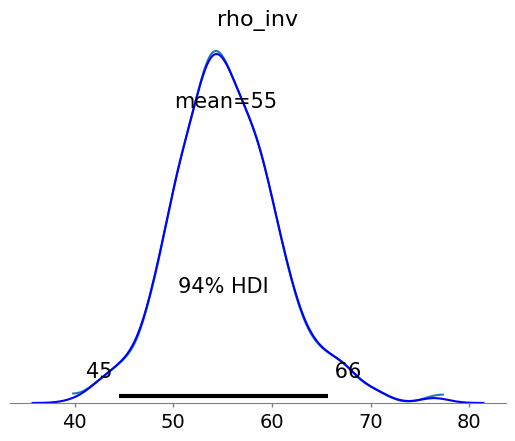

In [15]:
az.plot_posterior(data_neutral, var_names=['rho_inv'], kind='kde')
# sns.histplot(data_neutral.rho_inv, kde=False, bins=30)
sns.kdeplot(data_neutral.rho_inv, color='Blue')

# calculate confidence interval for rho_inv

print(np.quantile(data_neutral.rho_inv, 0.025))
print(np.quantile(data_neutral.rho_inv, 0.975))


-7965.940500000001
11163.56749999999


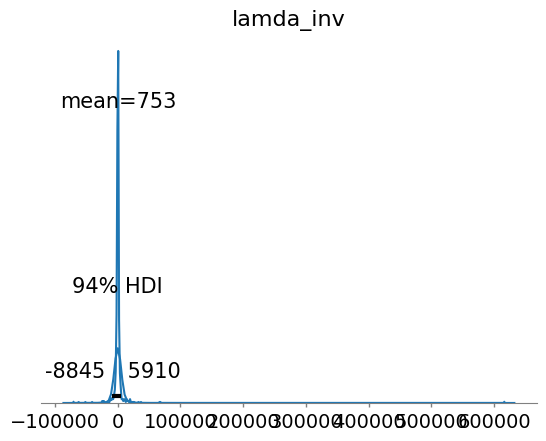

In [16]:
az.plot_posterior(data_neutral, var_names=['lamda_inv'], kind='kde')
sns.kdeplot(data_neutral.lamda_inv)

print(np.quantile(data_neutral.lamda_inv, 0.025))
print(np.quantile(data_neutral.lamda_inv, 0.975))

0.0040619309999999995
0.0066642049999999994


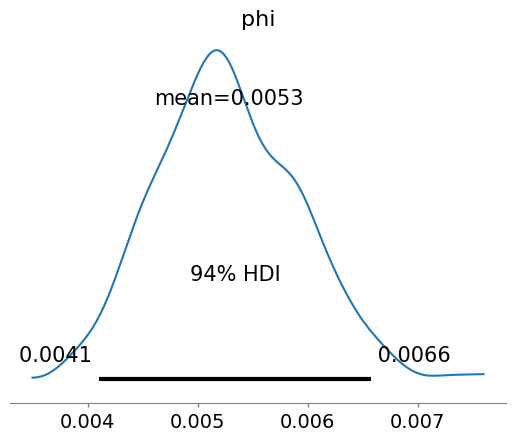

In [17]:
az.plot_posterior(data_neutral, var_names=['phi'], kind = 'kde')

print(np.quantile(data_neutral.phi, 0.025))
print(np.quantile(data_neutral.phi, 0.975))

<Axes: title={'center': 'delta'}>

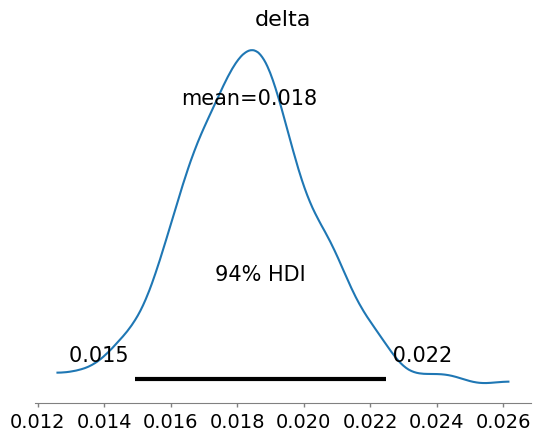

In [18]:
az.plot_posterior(data_neutral, var_names=['delta'], kind = 'kde')

<Axes: title={'center': 'rho'}>

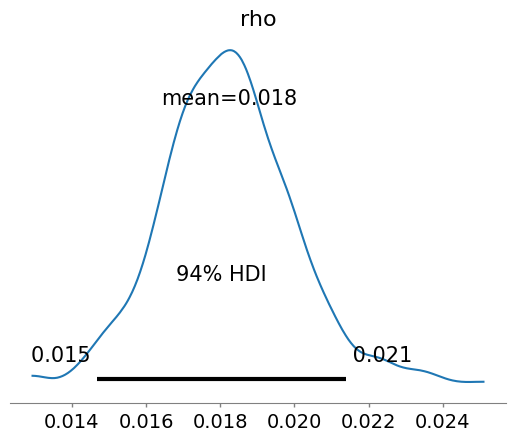

In [19]:
az.plot_posterior(data_neutral, var_names=['rho'], kind = 'kde')

In [20]:
az.plot_posterior(data_neutral, var_names=['y0'], kind = 'kde')

KeyError: 'var names: "[\'y0\'] are not present" in dataset'

0.161421737345


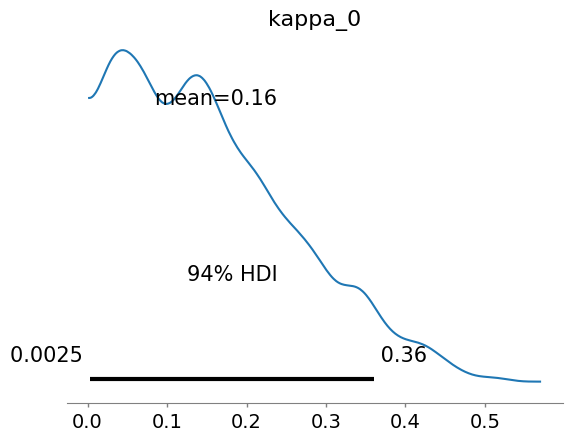

In [ ]:
az.plot_posterior(data_neutral, var_names=['kappa_0'], kind = 'kde')
print(np.mean(data_neutral.kappa_0))

40.091765
62.04844749999999


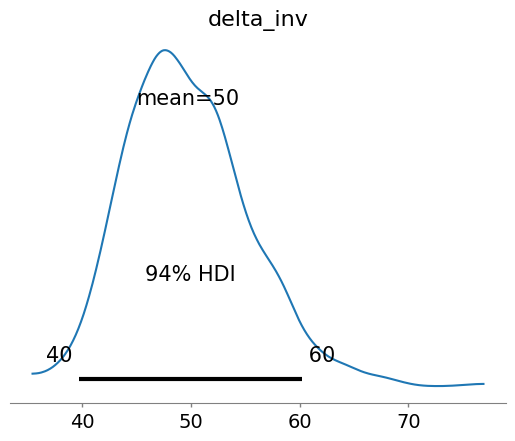

In [ ]:
az.plot_posterior(data_neutral, var_names=['delta_inv'], kind='kde')

print(np.quantile(data_neutral.delta_inv, 0.025))
print(np.quantile(data_neutral.delta_inv, 0.975))

In [ ]:
#Plot the posterior distribution of the parameters
az.plot_posterior(data_neutral, var_names=['phi', 'rho_inv', 'beta','delta_inv'], kind='kde')








KeyError: 'var names: "[\'beta\'] are not present" in dataset'